In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split

home_data = pd.read_csv("./dataset/train.csv")

print (home_data.describe())
print (home_data.columns)

features = ['Rooms', 'Bathroom', 'Distance', 'Landsize', 'Type', 'Regionname']

X = pd.get_dummies(home_data[features])
y = home_data['Price']

train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=1)

              Rooms         Price      Distance      Postcode      Bedroom2  \
count  13580.000000  1.358000e+04  13580.000000  13580.000000  13580.000000   
mean       2.937997  1.075684e+06     10.137776   3105.301915      2.914728   
std        0.955748  6.393107e+05      5.868725     90.676964      0.965921   
min        1.000000  8.500000e+04      0.000000   3000.000000      0.000000   
25%        2.000000  6.500000e+05      6.100000   3044.000000      2.000000   
50%        3.000000  9.030000e+05      9.200000   3084.000000      3.000000   
75%        3.000000  1.330000e+06     13.000000   3148.000000      3.000000   
max       10.000000  9.000000e+06     48.100000   3977.000000     20.000000   

           Bathroom           Car       Landsize  BuildingArea    YearBuilt  \
count  13580.000000  13518.000000   13580.000000   7130.000000  8205.000000   
mean       1.534242      1.610075     558.416127    151.967650  1964.684217   
std        0.691712      0.962634    3990.669241   

In [ ]:
from lazypredict.Supervised import LazyRegressor

lazy = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

models, predictions = lazy.fit(train_X, test_X, train_y, test_y)

print(models)

                               Adjusted R-Squared    R-Squared          RMSE  \
Model                                                                          
HistGradientBoostingRegressor            0.829229     0.830437  2.552901e+05   
RandomForestRegressor                    0.816971     0.818266  2.642938e+05   
ExtraTreesRegressor                      0.810156     0.811499  2.691691e+05   
BaggingRegressor                         0.802653     0.804049  2.744368e+05   
GradientBoostingRegressor                0.777267     0.778842  2.915547e+05   
KNeighborsRegressor                      0.675165     0.677462  3.520938e+05   
DecisionTreeRegressor                    0.635289     0.637868  3.730796e+05   
LassoCV                                  0.603118     0.605925  3.891867e+05   
LassoLarsCV                              0.602573     0.605383  3.894540e+05   
LarsCV                                   0.602573     0.605383  3.894540e+05   
LassoLarsIC                             

In [56]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

hgbr_model = HistGradientBoostingRegressor(random_state=1)

hgbr_model.fit(train_X, train_y)

hgbr_preds = hgbr_model.predict(test_X)

hgbr_mae = mean_absolute_error(test_y, hgbr_preds)
hgbr_mape = mean_absolute_percentage_error(test_y, hgbr_preds)
hgbr_accuracy = 100 - (hgbr_mape * 100)

print(f"Mean Absolute Error of HistGradientBoosting (MAE): {hgbr_mae:.0f}")
print(f"Mean Absolute Percentage Error of HistGradientBoosting (MAPE): {hgbr_mape * 100:.2f}%")
print(f"New HistGradientBoosting Accuracy: {hgbr_accuracy:.2f}%")

Mean Absolute Error of HistGradientBoosting (MAE): 180722
Mean Absolute Percentage Error of HistGradientBoosting (MAPE): 17.16%
New HistGradientBoosting Accuracy: 82.84%


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

dt_model = DecisionTreeRegressor(random_state=1)
dt_model.fit(train_X, train_y)

dt_preds = dt_model.predict(test_X)

dt_mae = mean_absolute_error(test_y, dt_preds)
dt_mape = mean_absolute_percentage_error(test_y, dt_preds)

dt_accuracy = 100 - (dt_mape * 100)

print(f"Mean Absolute Error of Decision Tree (MAE): {dt_mae:.0f}")
print(f"Mean Absolute Percentage Error of Decision Tree (MAPE): {dt_mape * 100:.2f}%")
print(f"Model Accuracy of Decision Tree: {dt_accuracy:.2f}%")

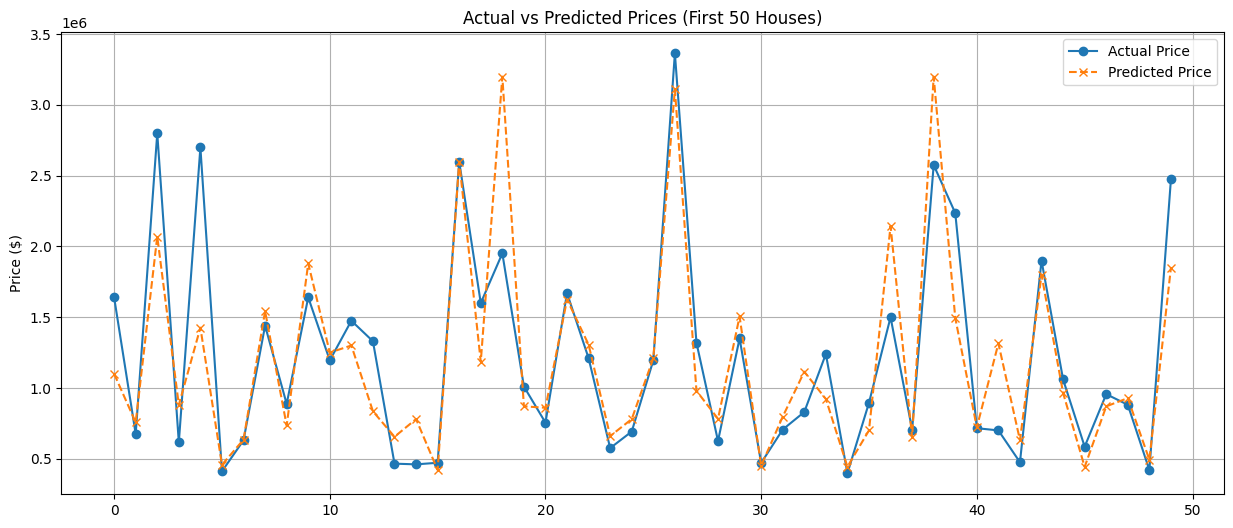

In [21]:
# Comparison between actual and predicted prices for first 50 houses for Decision Tree

comparison = pd.DataFrame({'Actual': test_y, 'Predicted': dt_preds})

plt.figure(figsize=(15, 6))
plt.plot(comparison['Actual'].values[:50], label='Actual Price', marker='o')
plt.plot(comparison['Predicted'].values[:50], label='Predicted Price', marker='x', linestyle='--')
plt.title("Actual vs Predicted Prices (First 50 Houses)")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Actual vs Predicted')

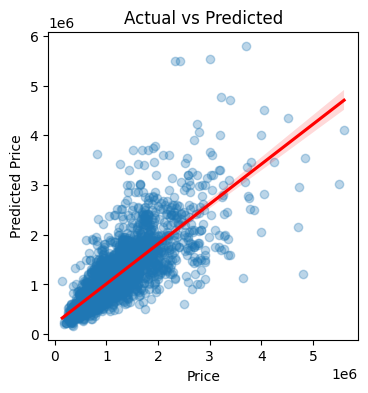

In [23]:
# Regression plot for Decision Tree

plt.figure(figsize=(4, 4))

sns.regplot(x=test_y, y=dt_preds, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

In [52]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=1)
rf_model.fit(train_X, train_y)

rf_preds = rf_model.predict(test_X)

rf_mae = mean_absolute_error(test_y, rf_preds)
rf_mape = mean_absolute_percentage_error(test_y, rf_preds)

rf_accuracy = 100 - (rf_mape * 100)

print(f"Mean Absolute Error (MAE) of Random Forest: {rf_mae:.0f}")
print(f"Mean Absolute Percentage Error (MAPE) of Random Forest: {rf_mape * 100:.2f}%")
print(f"Model Accuracy of Random Forest: {rf_accuracy:.2f}%")

Mean Absolute Error (MAE) of Random Forest: 189550
Mean Absolute Percentage Error (MAPE) of Random Forest: 17.63%
Model Accuracy of Random Forest: 82.37%


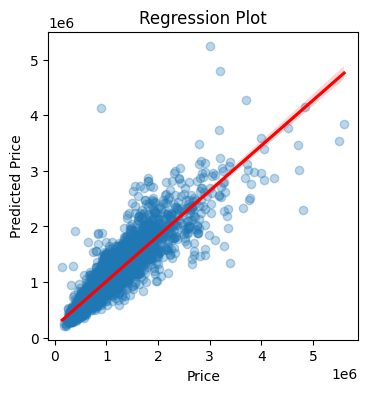

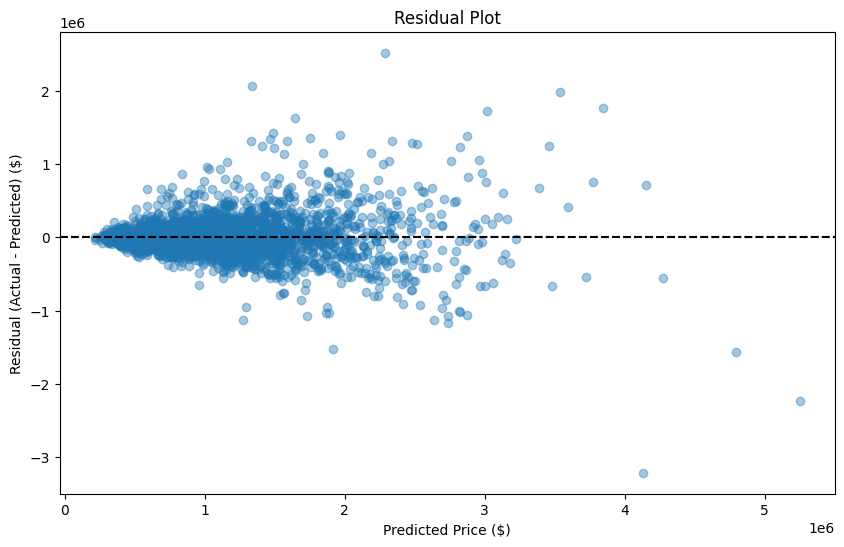

In [49]:
# Regression and Residual plots for Random Forest

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 4))

sns.regplot(x=test_y, y=rf_preds, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.ylabel("Predicted Price")
plt.title("Regression Plot")

# 1. Calculate the residuals (The Errors)
residuals = test_y - rf_preds

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.residplot(x=rf_preds, y=residuals, lowess=False, 
              line_kws={'color': 'red', 'lw': 2}, 
              scatter_kws={'alpha': 0.4})

plt.axhline(y=0, color='black', linestyle='--') # Add a horizontal line at 0
plt.title('Residual Plot')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual (Actual - Predicted) ($)')
plt.show()